# Relational analysis - Chekpoint 3

In [2]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

The following analysis was developed based on a social network graph. The graph represents the interaction in Twitter of US congress' members, where each node represents a person that is part of the congress, and the edges (weighted) their connection (retweet, quote tweet, reply, or mention  of another member). In summary, this graph represents the spreading of opinion/ideas among the members of the US congress.

This network dataset was extracted from https://snap.stanford.edu/data/congress-twitter.html

# **Loading social network graph**

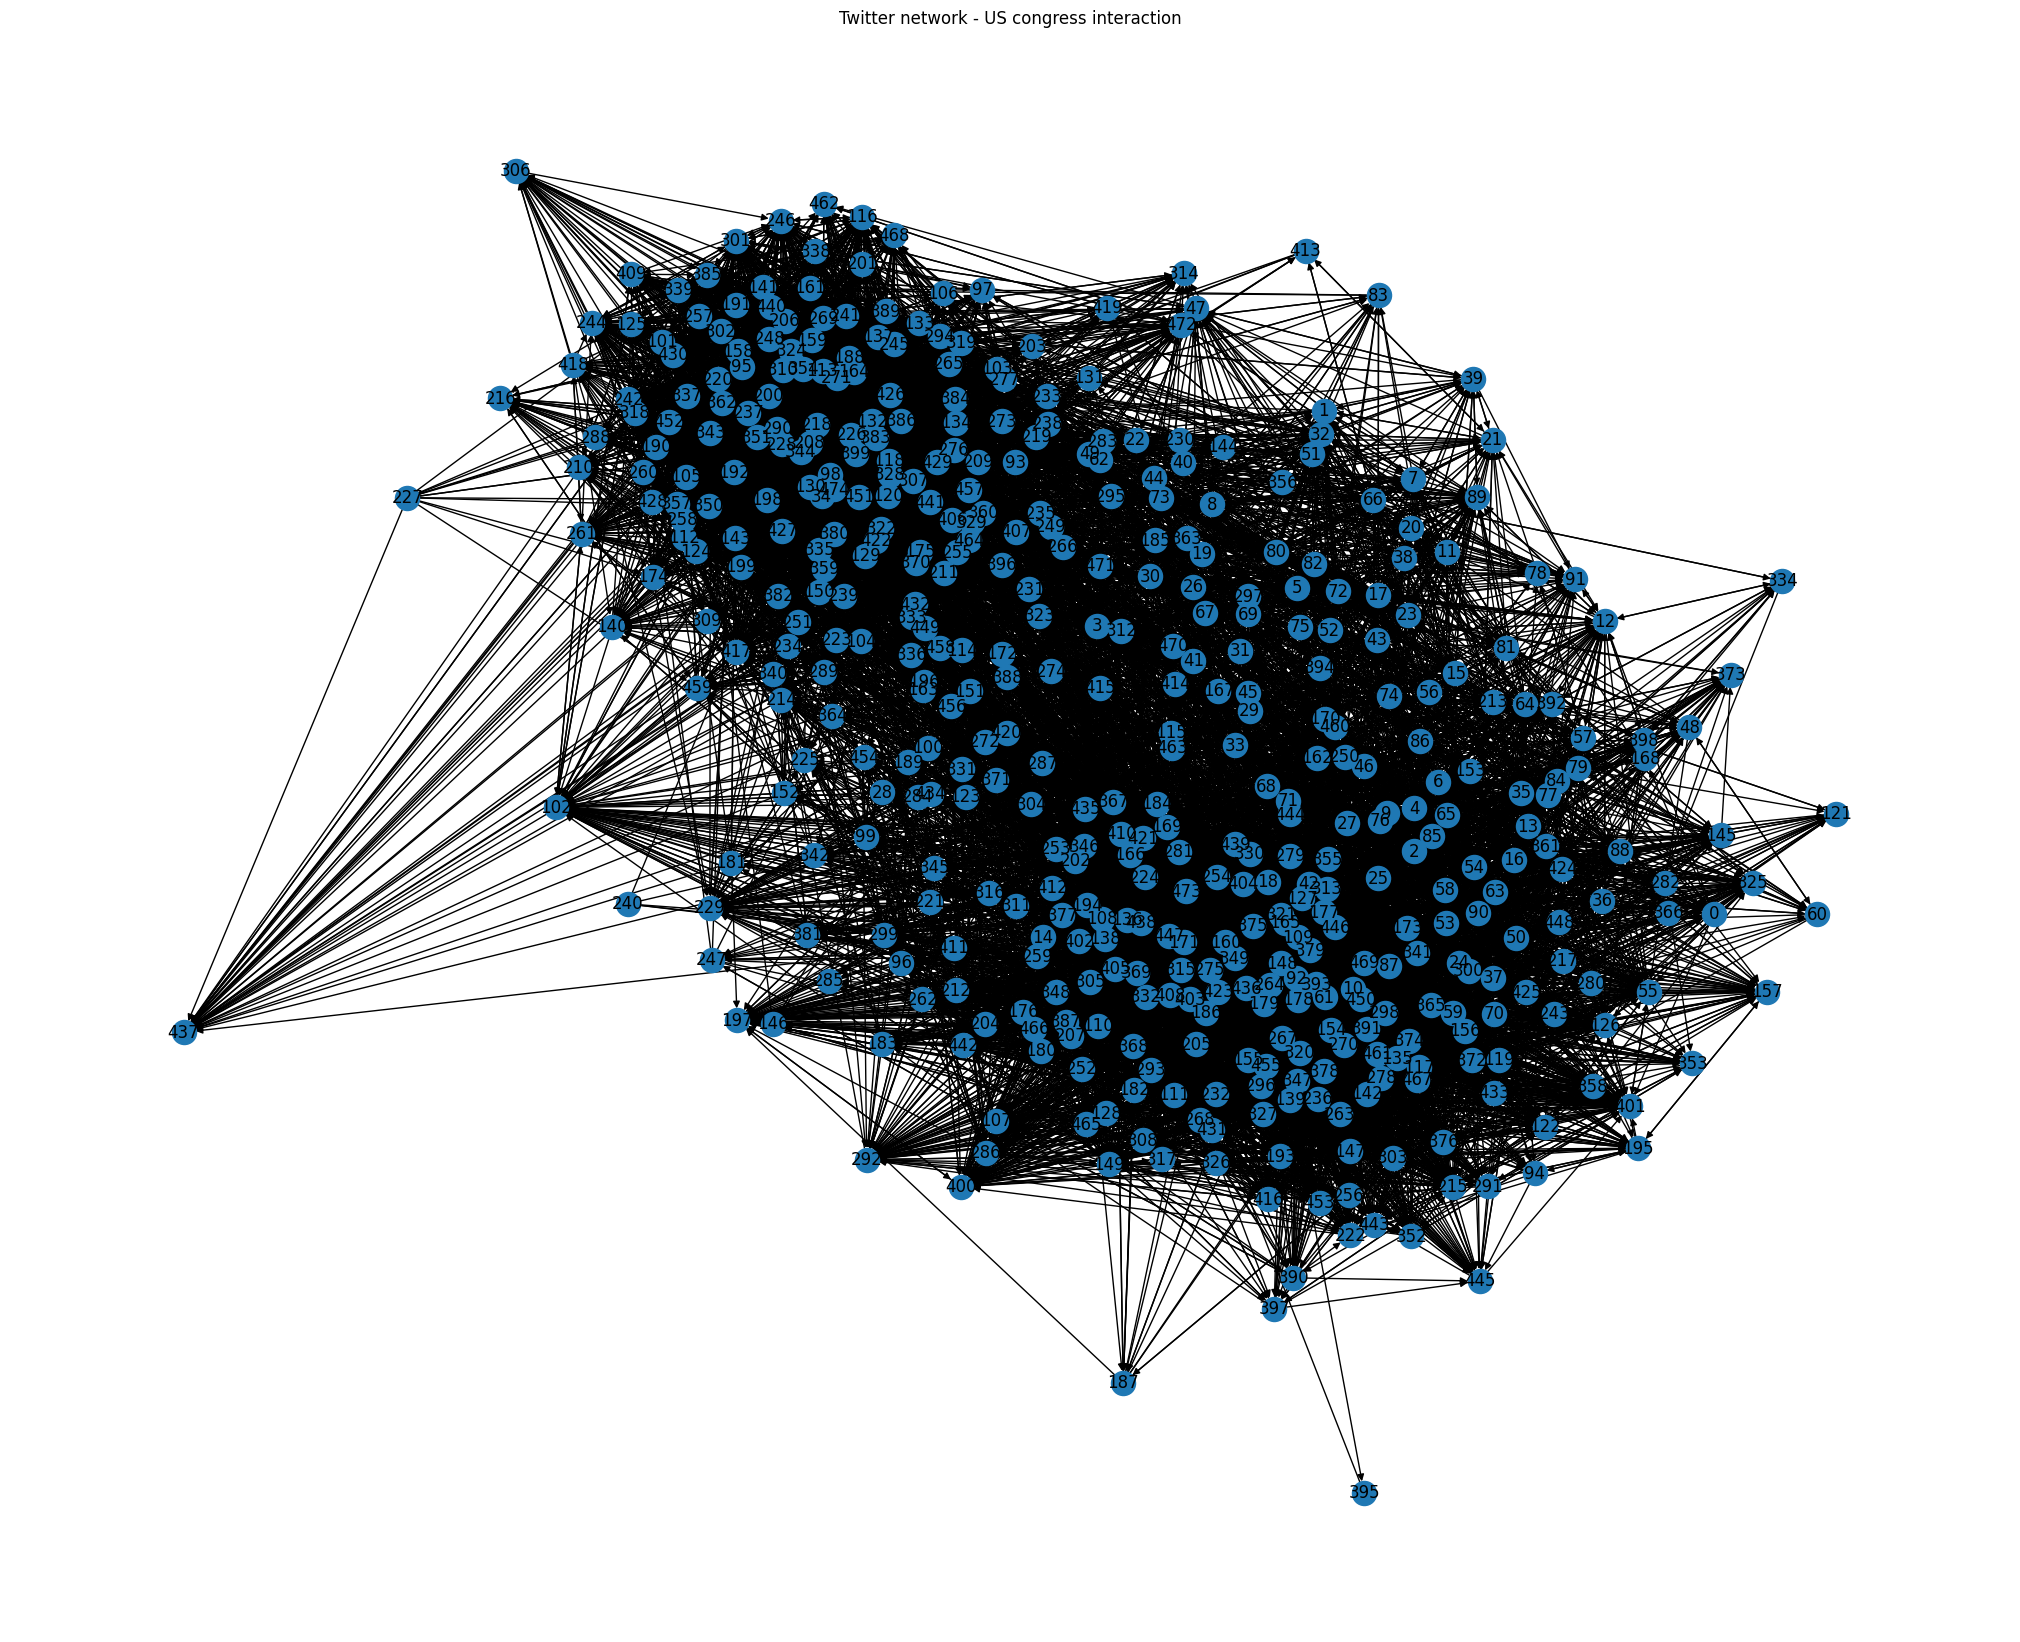

In [3]:
G = nx.read_edgelist('./data/congress_network/congress.edgelist', create_using=nx.DiGraph(), data=True)

plt.figure(figsize=(20, 16))

nx.draw(G, with_labels=True)

plt.title('Twitter network - US congress interaction')
plt.show()

# General statistics and characteristics

In [11]:
def graph_characteristics(G):
    """
    Analyzes a directed social network graph and returns key statistics
    
    Parameters:
    G: NetworkX DiGraph object
    
    Returns:
    Dictionary with network statistics
    """
    
    stats = {}
    
    # 1. Basic Structure
    stats['num_nodes'] = G.number_of_nodes()
    stats['num_edges'] = G.number_of_edges()
    stats['is_directed'] = G.is_directed()

    if stats['is_directed'] == True:
        stats['is_directed'] = 'Yes'
    else:
        stats['is_directed'] = 'No:('
    
    # 2. Degree Statistics
    degrees = [d for n, d in G.degree()]
    stats['average_degree'] = sum(degrees) / len(degrees) if degrees else 0
    
    # 3. Density
    stats['density'] = nx.density(G)
    
    # 4. Clustering Coefficient
    # For directed graphs, we convert to undirected for clustering
    G_undirected = G.to_undirected()
    stats['clustering_coefficient'] = nx.average_clustering(G_undirected)
    
    # 5. Centrality Measures (top 10 nodes)
    in_centrality = nx.in_degree_centrality(G)
    out_centrality = nx.out_degree_centrality(G)
    total_centrality = nx.degree_centrality(G)
    
    stats['top_in_centrality'] = sorted(in_centrality.items(), 
                                        key=lambda x: x[1], 
                                        reverse=True)[:10]
    stats['top_out_centrality'] = sorted(out_centrality.items(), 
                                         key=lambda x: x[1], 
                                         reverse=True)[:10]
    stats['top_total_centrality'] = sorted(total_centrality.items(), 
                                         key=lambda x: x[1], 
                                         reverse=True)[:10]
    
    # 6. Strongly Connected Components
    sccs = list(nx.strongly_connected_components(G))
    stats['num_strongly_connected_components'] = len(sccs)
    stats['largest_scc_size'] = len(max(sccs, key=len)) if sccs else 0
    
    # 7. Largest Connected Component (weakly connected for directed graphs)
    wccs = list(nx.weakly_connected_components(G))
    largest_wcc = max(wccs, key=len) if wccs else set()
    stats['largest_connected_component_size'] = len(largest_wcc)
    
    # 8. Average Path Length (only for largest connected component)
    if largest_wcc:
        largest_subgraph = G.subgraph(largest_wcc)
        # For directed graphs, convert to undirected for path length
        largest_undirected = largest_subgraph.to_undirected()
        
        if nx.is_connected(largest_undirected):
            stats['average_path_length'] = nx.average_shortest_path_length(largest_undirected)
        else:
            stats['average_path_length'] = None
    else:
        stats['average_path_length'] = None
    
    return stats


# Function to print statistics in a readable format
def print_network_stats(stats):
    """
    Prints network statistics in a formatted way
    """
    print("=" * 60)
    print("SOCIAL NETWORK GRAPH STATISTICS")
    print("=" * 60)
    
    print("\nBASIC STRUCTURE")
    print(f"  • Number of Nodes: {stats['num_nodes']}")
    print(f"  • Number of Edges: {stats['num_edges']}")
    print(f"  • Directed Graph: {stats['is_directed']}")
    
    print("\nCONNECTIVITY METRICS")
    print(f"  • Average Degree: {stats['average_degree']:.2f}")
    print(f"  • Density: {stats['density']:.4f}")
    print(f"  • Clustering Coefficient: {stats['clustering_coefficient']:.4f}")
    
    print("\n CENTRALITY (Top 10 most influential persons)")
    print("\n  IN-DEGREE:")
    for i, (node, centrality) in enumerate(stats['top_in_centrality'], 1):
        print(f"    {i}. {node}: {centrality:.4f}")
    
    print("\nOUT-DEGREE:")
    for i, (node, centrality) in enumerate(stats['top_out_centrality'], 1):
        print(f"    {i}. {node}: {centrality:.4f}")
    
    print("\nTOTAL DEGREE:")
    for i, (node, centrality) in enumerate(stats['top_total_centrality'], 1):
        print(f"    {i}. {node}: {centrality:.4f}")
    
    print("\nCOMPONENT ANALYSIS")
    print(f"  • Number of Strongly Connected Components: {stats['num_strongly_connected_components']}")
    print(f"  • Largest SCC Size: {stats['largest_scc_size']}")
    print(f"  • Largest Connected Component: {stats['largest_connected_component_size']} nodes")
    
    if stats['average_path_length']:
        print(f"  • Average Path Length: {stats['average_path_length']:.2f}")
    else:
        print(f"  • Average Path Length: N/A (graph not connected)")
    
    print("=" * 60)

In [12]:
graph_measures = graph_characteristics(G)
print_network_stats(graph_measures)

SOCIAL NETWORK GRAPH STATISTICS

BASIC STRUCTURE
  • Number of Nodes: 475
  • Number of Edges: 13289
  • Directed Graph: Yes

CONNECTIVITY METRICS
  • Average Degree: 55.95
  • Density: 0.0590
  • Clustering Coefficient: 0.3014

 CENTRALITY (Top 10 most influential persons)

  IN-DEGREE:
    1. 322: 0.2679
    2. 208: 0.2553
    3. 190: 0.2532
    4. 111: 0.2300
    5. 254: 0.2278
    6. 385: 0.2278
    7. 269: 0.2236
    8. 192: 0.2215
    9. 147: 0.2046
    10. 303: 0.2046

OUT-DEGREE:
    1. 367: 0.4430
    2. 322: 0.3312
    3. 393: 0.2342
    4. 71: 0.2046
    5. 399: 0.1878
    6. 436: 0.1793
    7. 179: 0.1772
    8. 254: 0.1667
    9. 105: 0.1582
    10. 87: 0.1498

TOTAL DEGREE:
    1. 322: 0.5992
    2. 367: 0.5506
    3. 393: 0.4008
    4. 254: 0.3945
    5. 208: 0.3840
    6. 303: 0.3439
    7. 269: 0.3439
    8. 190: 0.3312
    9. 399: 0.3207
    10. 111: 0.3122

COMPONENT ANALYSIS
  • Number of Strongly Connected Components: 7
  • Largest SCC Size: 469
  • Largest Connect

In [13]:
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')
from networkx.algorithms import community

def detect_communities(G, method='louvain'):
    """
    Detects communities in a directed graph using various algorithms
    
    Parameters:
    G: NetworkX DiGraph object
    method: str - 'louvain', 'label_propagation', 'girvan_newman', or 'greedy_modularity'
    
    Returns:
    Dictionary mapping nodes to community IDs
    """
    
    # Convert directed graph to undirected for community detection
    G_undirected = G.to_undirected()
    
    print(f"Detecting communities using {method.upper()} method...")
    
    if method == 'louvain':
        # Louvain requires the python-louvain package
        # We'll use greedy_modularity_communities as an alternative
        communities_generator = community.greedy_modularity_communities(G_undirected, weight='weight')
        communities = list(communities_generator)
        
    elif method == 'label_propagation':
        communities_generator = community.label_propagation_communities(G_undirected)
        communities = list(communities_generator)
        
    elif method == 'girvan_newman':
        # Girvan-Newman returns a generator of community divisions
        # We take the first level (most granular)
        communities_generator = community.girvan_newman(G_undirected)
        # Get a reasonable number of communities (tune this parameter)
        for _ in range(3):  # Adjust iterations for more/fewer communities
            try:
                communities = next(communities_generator)
            except StopIteration:
                break
        communities = list(communities)
        
    elif method == 'greedy_modularity':
        communities_generator = community.greedy_modularity_communities(G_undirected)
        communities = list(communities_generator)
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Convert to dictionary format: {node: community_id}
    node_to_community = {}
    for i, comm in enumerate(communities):
        for node in comm:
            node_to_community[node] = i
    
    return node_to_community, communities


def analyze_communities(G, node_to_community, communities):
    """
    Analyzes community structure and returns statistics
    
    Parameters:
    G: NetworkX graph
    node_to_community: dict mapping nodes to community IDs
    communities: list of sets, each set contains nodes in a community
    
    Returns:
    Dictionary with community statistics
    """
    
    stats = {}
    stats['num_communities'] = len(communities)
    stats['community_sizes'] = [len(comm) for comm in communities]
    stats['largest_community'] = max(stats['community_sizes'])
    stats['smallest_community'] = min(stats['community_sizes'])
    stats['average_community_size'] = np.mean(stats['community_sizes'])
    
    # Calculate modularity
    G_undirected = G.to_undirected()
    stats['modularity'] = community.modularity(G_undirected, communities)
    
    # Get top nodes in each community (by degree)
    stats['community_details'] = []
    for i, comm in enumerate(communities):
        subgraph = G.subgraph(comm)
        degrees = dict(subgraph.degree())
        top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]
        
        stats['community_details'].append({
            'id': i,
            'size': len(comm),
            'nodes': list(comm),
            'top_nodes': top_nodes
        })
    
    return stats


def print_community_stats(stats):
    """
    Prints community detection statistics in a formatted way
    """
    
    print(f"\nOVERALL STATISTICS")
    print(f"  • Number of Communities: {stats['num_communities']}")
    print(f"  • Modularity Score: {stats['modularity']:.4f}")
    print(f"  • Average Community Size: {stats['average_community_size']:.2f} nodes")
    print(f"  • Largest Community: {stats['largest_community']} nodes")
    print(f"  • Smallest Community: {stats['smallest_community']} nodes")
    
    print(f"\nCOMMUNITY DETAILS (sorted by size)")
    
    # Sort communities by size
    sorted_communities = sorted(stats['community_details'], 
                               key=lambda x: x['size'], 
                               reverse=True)
    
    for comm in sorted_communities:
        print(f"\n  Community {comm['id']} ({comm['size']} nodes)")
        print(f"    Top nodes by degree:")
        for node, degree in comm['top_nodes']:
            print(f"      • {node} (degree: {degree})")
    
    print("=" * 60)


def visualize_communities(G, node_to_community, title="Community Detection", 
                         figsize=(16, 12), layout='spring'):
    """
    Visualizes the graph with communities highlighted in different colors
    
    Parameters:
    G: NetworkX graph
    node_to_community: dict mapping nodes to community IDs
    title: str - plot title
    figsize: tuple - figure size
    layout: str - 'spring', 'kamada_kawai', or 'circular'
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Choose layout algorithm
    if layout == 'spring':
        pos = nx.spring_layout(G, k=1, iterations=50, seed=42)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    
    # Get unique communities and assign colors
    unique_communities = sorted(set(node_to_community.values()))
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_communities)))
    community_colors = {comm_id: colors[i] for i, comm_id in enumerate(unique_communities)}
    
    # Map each node to its color
    node_colors = [community_colors[node_to_community[node]] for node in G.nodes()]
    
    # Calculate node sizes based on degree
    node_sizes = [G.degree(node) * 100 + 100 for node in G.nodes()]
    
    # PLOT 1: Full network with communities
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=0.8, 
                          edgecolors='black', linewidths=1.5, ax=ax1)
    
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                          alpha=0.2, arrows=True, 
                          arrowsize=10, arrowstyle='->', ax=ax1)
    
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold', ax=ax1)
    
    ax1.set_title(f"{title}\n({len(unique_communities)} communities detected)", 
                  fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # PLOT 2: Community distribution (bar chart)
    community_sizes = {}
    for node, comm in node_to_community.items():
        community_sizes[comm] = community_sizes.get(comm, 0) + 1
    
    sorted_communities = sorted(community_sizes.items())
    comm_ids = [f"C{c}" for c, _ in sorted_communities]
    sizes = [s for _, s in sorted_communities]
    bar_colors = [community_colors[c] for c, _ in sorted_communities]
    
    ax2.bar(comm_ids, sizes, color=bar_colors, edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Community ID', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Nodes', fontsize=12, fontweight='bold')
    ax2.set_title('Community Size Distribution', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # Rotate x-axis labels if many communities
    if len(comm_ids) > 10:
        ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


def visualize_largest_communities(G, node_to_community, top_n=3, figsize=(18, 6)):
    """
    Visualizes the largest N communities separately for detailed inspection
    
    Parameters:
    G: NetworkX graph
    node_to_community: dict mapping nodes to community IDs
    top_n: int - number of largest communities to visualize
    """
    
    # Count nodes in each community
    community_sizes = {}
    for node, comm in node_to_community.items():
        community_sizes[comm] = community_sizes.get(comm, 0) + 1
    
    # Get top N largest communities
    largest_communities = sorted(community_sizes.items(), 
                                key=lambda x: x[1], 
                                reverse=True)[:top_n]
    
    fig, axes = plt.subplots(1, top_n, figsize=figsize)
    
    if top_n == 1:
        axes = [axes]
    
    colors = plt.cm.Set3(np.linspace(0, 1, top_n))
    
    for idx, (comm_id, size) in enumerate(largest_communities):
        # Get nodes in this community
        comm_nodes = [node for node, comm in node_to_community.items() if comm == comm_id]
        subgraph = G.subgraph(comm_nodes)
        
        # Layout for this subgraph
        pos = nx.spring_layout(subgraph, k=0.5, iterations=50, seed=42)
        
        # Node sizes based on degree within community
        node_sizes = [subgraph.degree(node) * 150 + 100 for node in subgraph.nodes()]
        
        # Draw
        nx.draw_networkx_nodes(subgraph, pos, node_color=[colors[idx]], 
                              node_size=node_sizes, alpha=0.8, 
                              edgecolors='black', linewidths=1.5, ax=axes[idx])
        
        nx.draw_networkx_edges(subgraph, pos, edge_color='gray', 
                              alpha=0.3, arrows=True, 
                              arrowsize=10, ax=axes[idx])
        
        nx.draw_networkx_labels(subgraph, pos, font_size=8, 
                               font_weight='bold', ax=axes[idx])
        
        axes[idx].set_title(f"Community {comm_id}\n({size} nodes)", 
                           fontsize=12, fontweight='bold')
        axes[idx].axis('off')
    
    plt.suptitle('Largest Communities (Detailed View)', 
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# MAIN EXECUTION FUNCTION
def perform_community_analysis(G, method='greedy_modularity'):
    """
    Complete community detection and visualization pipeline
    
    Parameters:
    G: NetworkX DiGraph
    method: str - community detection method
    """
    
    print(f"\n{'='*60}")
    print(f"Starting Community Detection Analysis")
    print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"{'='*60}\n")
    
    # Step 1: Detect communities
    node_to_community, communities = detect_communities(G, method=method)
    
    # Step 2: Analyze communities
    stats = analyze_communities(G, node_to_community, communities)
    
    # Step 3: Print statistics
    print_community_stats(stats)
    
    # Step 4: Visualize
    print("\nGenerating visualizations...")
    visualize_communities(G, node_to_community, 
                         title=f"IT Jobs Network - {method.upper()} Method")
    
    # Step 5: Detailed view of largest communities
    if stats['num_communities'] >= 3:
        visualize_largest_communities(G, node_to_community, top_n=min(3, stats['num_communities']))
    
    return node_to_community, communities, stats


Starting Community Detection Analysis
Graph: 475 nodes, 13289 edges

Detecting communities using GREEDY_MODULARITY method...

OVERALL STATISTICS
  • Number of Communities: 3
  • Modularity Score: 0.3998
  • Average Community Size: 158.33 nodes
  • Largest Community: 248 nodes
  • Smallest Community: 45 nodes

COMMUNITY DETAILS (sorted by size)

  Community 0 (248 nodes)
    Top nodes by degree:
      • 367 (degree: 186)
      • 393 (degree: 185)
      • 254 (degree: 171)
      • 303 (degree: 155)
      • 147 (degree: 141)

  Community 1 (182 nodes)
    Top nodes by degree:
      • 322 (degree: 256)
      • 208 (degree: 168)
      • 269 (degree: 158)
      • 399 (degree: 145)
      • 190 (degree: 136)

  Community 2 (45 nodes)
    Top nodes by degree:
      • 17 (degree: 50)
      • 72 (degree: 39)
      • 32 (degree: 37)
      • 66 (degree: 36)
      • 26 (degree: 33)

Generating visualizations...


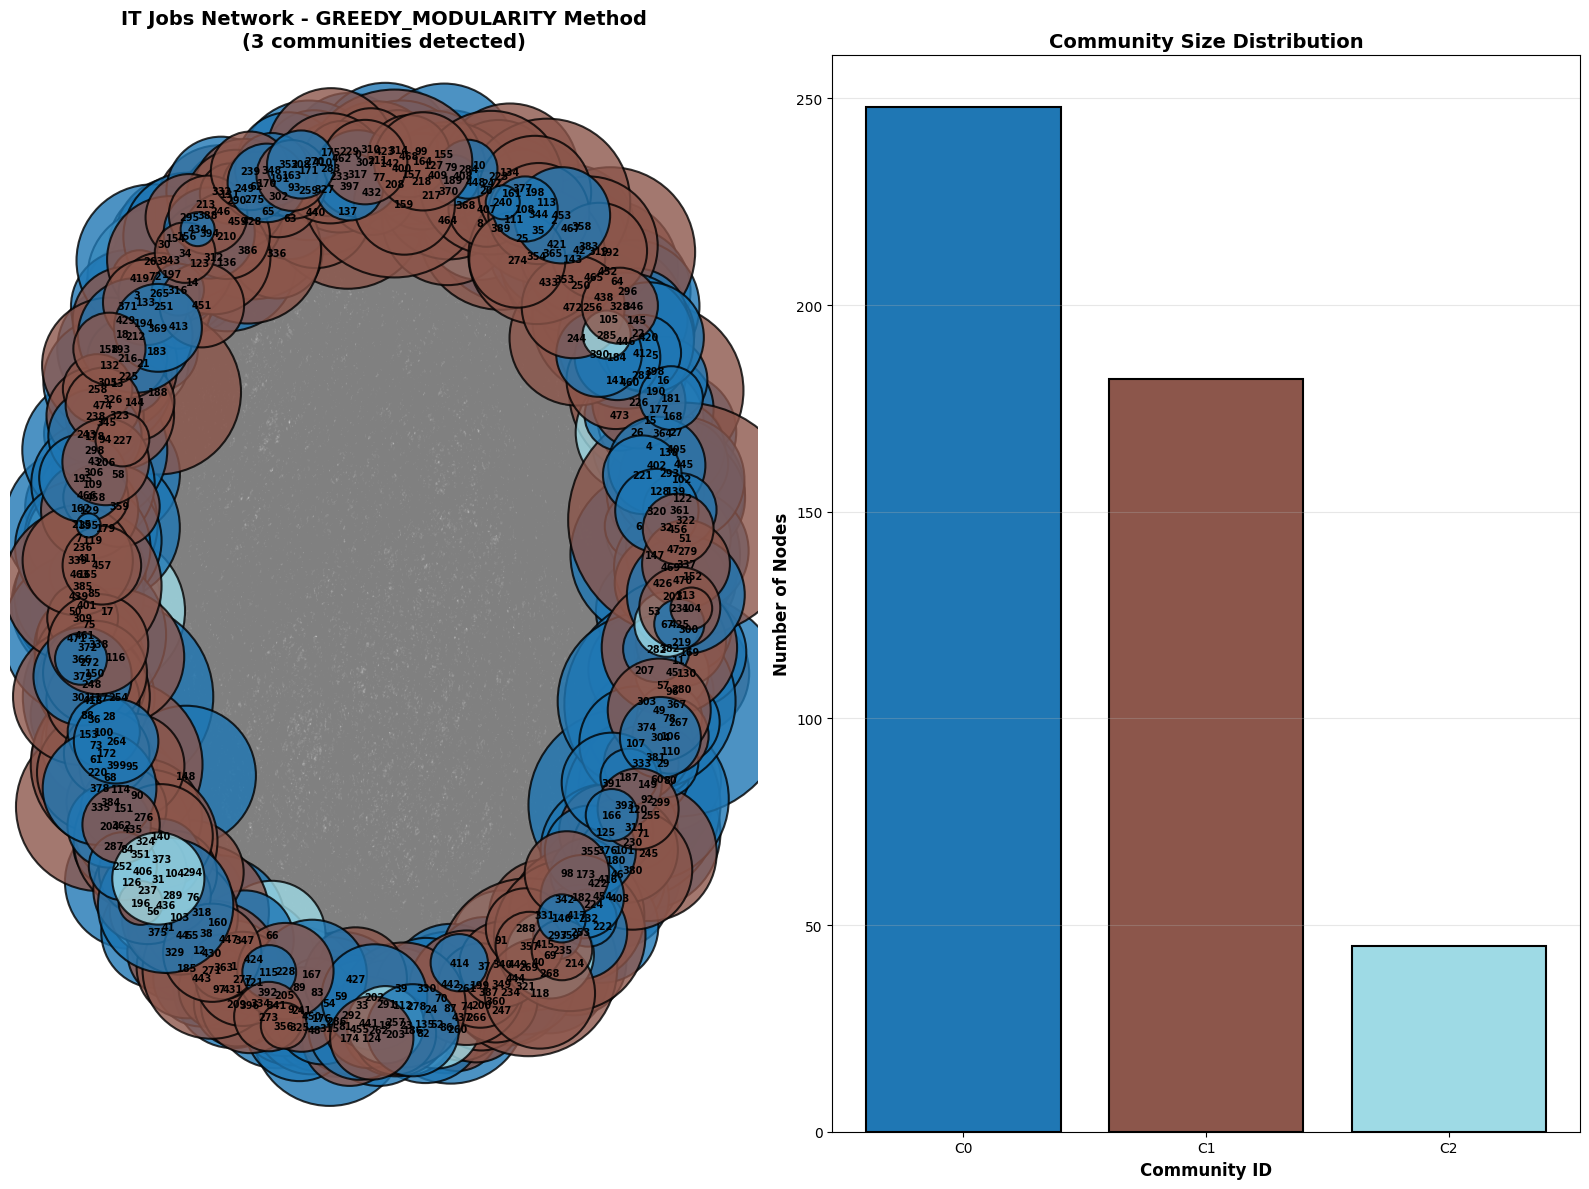

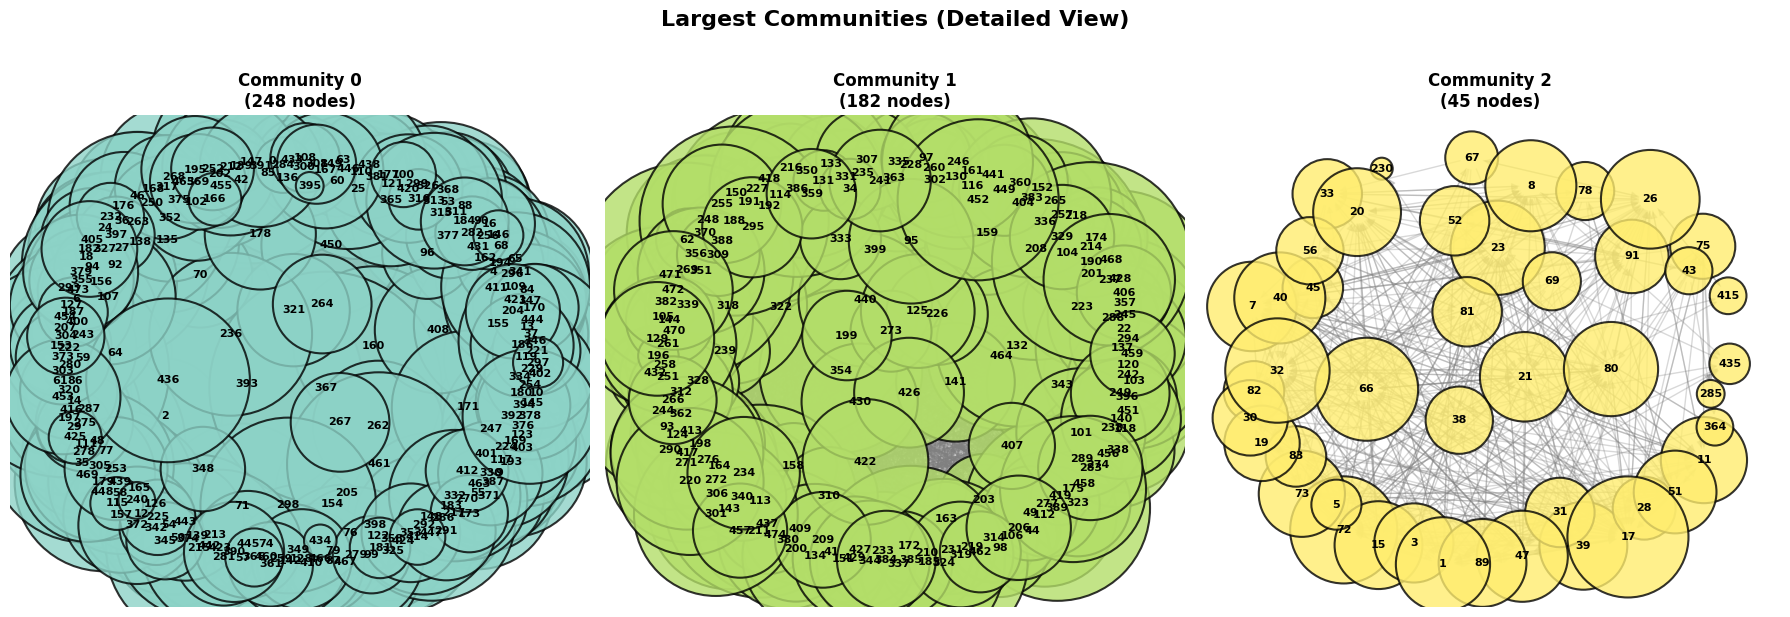

{'445': 0,
 '212': 0,
 '416': 0,
 '169': 0,
 '304': 0,
 '178': 0,
 '303': 0,
 '90': 0,
 '278': 0,
 '109': 0,
 '77': 0,
 '24': 0,
 '381': 0,
 '401': 0,
 '421': 0,
 '448': 0,
 '321': 0,
 '148': 0,
 '50': 0,
 '332': 0,
 '59': 0,
 '25': 0,
 '327': 0,
 '378': 0,
 '377': 0,
 '347': 0,
 '61': 0,
 '450': 0,
 '443': 0,
 '297': 0,
 '412': 0,
 '205': 0,
 '454': 0,
 '2': 0,
 '264': 0,
 '275': 0,
 '317': 0,
 '162': 0,
 '447': 0,
 '349': 0,
 '358': 0,
 '64': 0,
 '423': 0,
 '460': 0,
 '184': 0,
 '240': 0,
 '136': 0,
 '299': 0,
 '466': 0,
 '473': 0,
 '63': 0,
 '194': 0,
 '154': 0,
 '361': 0,
 '400': 0,
 '183': 0,
 '54': 0,
 '221': 0,
 '308': 0,
 '348': 0,
 '127': 0,
 '181': 0,
 '296': 0,
 '320': 0,
 '182': 0,
 '268': 0,
 '279': 0,
 '155': 0,
 '87': 0,
 '37': 0,
 '85': 0,
 '345': 0,
 '453': 0,
 '280': 0,
 '281': 0,
 '173': 0,
 '213': 0,
 '252': 0,
 '292': 0,
 '374': 0,
 '305': 0,
 '341': 0,
 '403': 0,
 '110': 0,
 '375': 0,
 '250': 0,
 '267': 0,
 '168': 0,
 '379': 0,
 '202': 0,
 '6': 0,
 '420': 0,
 '4':

In [14]:
node_to_community, communities, stats = perform_community_analysis(G, method='greedy_modularity')
node_to_community

# Centrality measures